## `Non Local Means`

Le débruitage Non-Local Means (NLM) est une méthode de débruitage par patchs qui exploite la redondance des motifs dans l’image, même à grande distance.
__`Idée de base:`__
- une image naturelle contient beaucoup de motifs qui se répètent (textures, briques, feuillage, etc.),
- pas seulement localement mais partout dans l’image.
- pour débruiter un pixel $i$, NLM ne se limite pas à un petit voisinage local,
- il cherche, dans une zone plus large ou toute l’image, des patchs similaires au patch centré en $i$.
- la valeur débruitée de $i$ est une moyenne pondérée des valeurs d’autres pixels $j$, 
- où le poids est d’autant plus grand que le patch autour de $j$ ressemble à celui de $i$.
__`Calcul des poids:`__
- on considère un patch $P_i$ de taille $(2w+1)×(2w+1)$ autour du pixel $i$.
- pour chaque pixel $j$ dans une fenêtre de recherche autour de $i$, on compare $P_i$ et $P_j$
- on regarde tous les pixels $j$ dans une fenêtre de recherche autour de $i$ (ie: un carré de rayon $W$).
- ​le poids est souvent de la forme: 
$$\omega(i,j)\alpha*\exp \Bigl( \large \frac{||P_i − P_j||_2^2}{−h_2} \Bigr)$$
__`Donc:`__ 
   - $P_i$ : vecteur ou bloc 2D représentant l’intensité autour de i.
   - $P_j$ : même chose autour de j.
   - ω(i,j) devient grand si $P_j$ ressemble beaucoup à $P_i$ , petit sinon.
   - h contrôle la décroissance (plus h est grand, plus on accepte des patchs différents).
   - α est un facteur de normalisation souvent choisi pour que $\sum_j \omega(i,j)=1$.
__`Formule typique`__: 

- Ensuite, le pixel débruité en $i$ est une moyenne pondérée des pixels $j$, avec ces poids :
$$ \hat{u}(i) = \sum_{j} w(i,j)\, v(j), \qquad \sum_{j} w(i,j) = 1 $$
- où $v$ est l’image bruitée et $w(i,j)$ dépend de la distance entre les patchs autour de $i$ et $j$.   

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

#from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

### `Patches in Images`
Cette partie est dédiée à l'étude des structures de patch dans les images 
Dimension de l'image $N = n \times n$.

In [3]:
n = 128
x, y = 100, 200 
print(f"[{y-n}:{y+n},{x-n}:{x+n}]")

[72:328,-28:228]


- Nous chargeons un image bruitée $f_0\in \mathcal{R}^N$.
- En Python l’indexation d’une image se fait en ligne, colonne = y, x.
- Les coordonnées x,y représente le centre du patch que l'on extrait dans l’image f.
  - y-n:y+n coupe verticalement (lignes).
  - x-n:x+n coupe horizontalement (colonnes).

In [4]:
from skimage.transform import rescale, resize
from skimage.util import crop

path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/lena.png'
imgtrue = load_image(name,n) 
print(imgtrue.shape)

f0 = imgtrue[y-n:y+n, x-n:x+n]
# équivalent conceptuel d'un rescale des valeurs dans [0,1]
f0 = f0.astype(np.float32)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-8)

(128, 128)


Affichage $f_0$ $f$.

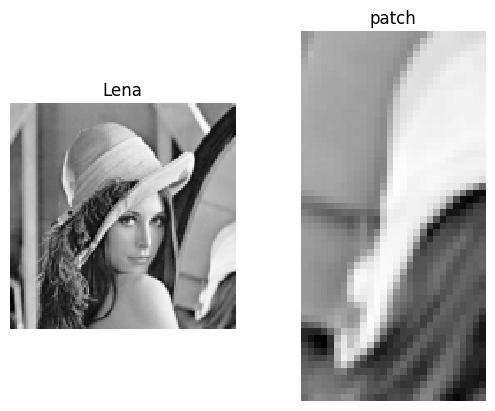

In [5]:
imageplot(clamp(imgtrue),'Lena',[1,2,1])
imageplot(clamp(f0),'patch',[1,2,2])

Ajouter un bruit gaussien additif $\epsilon$, tel que l'image bruitée $f=f_0+\epsilon$ où $\epsilon \approx \mathcal{N}(0,\sigma^2\text{Id}_N)$.
$\epsilon$ est un vecteur aléatoire gaussien de dimension $N$ (où $N$ est le nombre de pixels), de   
- moyenne nulle (centre en 0),  
- de matrice de covariance $\mathcal{N}(0,\sigma^2\text{Id}_N)$
Chaque pixel de bruit suit une loi normale $\mathcal{N}(0,\sigma^2)$, les composantes sont indépendantes entre elles.


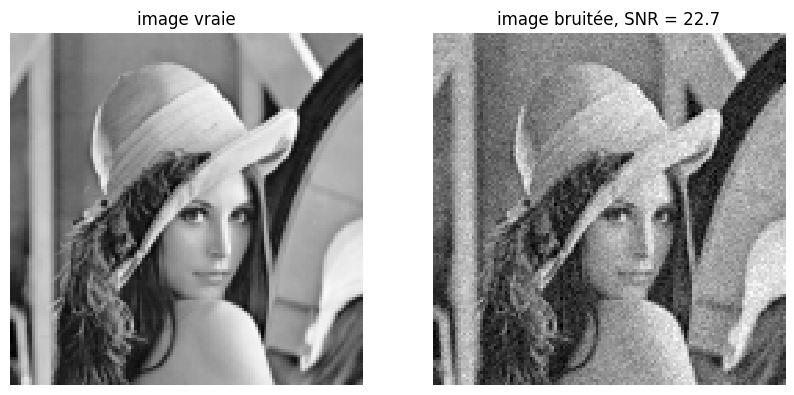

In [6]:
sigma = .04
imgnoised = imgtrue + np.random.randn(n,n)*sigma
plt.figure(figsize=(10, 10))
imageplot(clamp(imgtrue),'image vraie',[1,2,1])
imageplot(clamp(imgnoised),f"image bruitée, SNR = {snr(imgtrue,imgnoised):.3g}" , [1,2,2])

Nous construisons les coordonnées des patchs $7×7$ car $w=3$, donc $w_1 = 2 * w + 1 = 7$ autour de chaque pixel, en gérant les bords par réflexion. 
Nous construisons des matrices de tailles $(n,n,w_1,w_1)$ pour indexer les position de X et Y du pixel à extraire. 
- Localisation des pixels.
- Décalage (offsets)
- Localisation des pixels à extraire

In [7]:
w = 3
# Pour une réflexion symétrique
w1 = 2*w + 1

__Pour $w=3$, se réfère à un patch carré centré sur un pixel__.
- $w$ est la demi‑largeur, 
- $w$ demi‑hauteur du patch, 
- la distance en pixels entre le centre et chaque bord.
__La largeur totale du patch est $w1=2w+1$__
- Avec w=3, on a $w_1=2×3+1=7$.
`Concrètement, si le centre est au (x,y), le patch couvre` :
- horizontalement : $(x−3)$ , $(x−2)$ , $(x−1)$ , `(x)` , $(x+1)$ , $(x+2)$ , $(x+3)$ → 7 colonnes,
- verticalement   : $(y−3)$ , $(y−2)$ , $(y−1)$ , `(y)` , $(y+1)$ , $(y+2)$ , $(y+3)$ → 7 lignes.
Donc le patch est un carré de taille $7×7$ centré sur ce pixel.
- Xmesh, Ymesh (centres)

In [8]:
import numpy as np
# Paramètres et grilles de base
Ymesh, Xmesh = np.meshgrid(np.arange(n), np.arange(n),indexing='ij')
# Décalages dans le patch on crée les offsets du patch :
dYmesh, dXmesh = np.meshgrid(np.arange(-w,w+1),np.arange(-w,w+1))
# 
print(f"Xmesh  : {np.array(Xmesh).shape} , Ymesh  : {np.array(Ymesh).shape}")
print(f"dXmesh : {np.array(dXmesh).shape},      dYmesh : {np.array(dYmesh).shape}")

Xmesh  : (128, 128) , Ymesh  : (128, 128)
dXmesh : (7, 7),      dYmesh : (7, 7)


In [9]:
dX = dXmesh[None, None, :, :]    
dY = dYmesh[None, None, :, :]
# 
X = Xmesh[:, :, None, None] + dX
Y = Ymesh[:, :, None, None] + dY
# 
print(f"dY : {np.array(dY).shape},    dX : {np.array(dX).shape}") 
print(f"Y  : {np.array(Y).shape}, X : {np.array(X).shape}")

dY : (1, 1, 7, 7),    dX : (1, 1, 7, 7)
Y  : (128, 128, 7, 7), X : (128, 128, 7, 7)


#### __`Traiter les conditions limites des bords par réflexion`__ 
- pour traiter les bords de l’image lorsqu'un patch se trouve à l'extérieur, 
- on prolonge l’image, les pixels en dehors sont pris comme un miroir de ceux à l’intérieur.
__Pour une réflexion symétrique__
Sur $[0, n-1]$, le schéma typique 1D est pour le padding miroir parmi d'autres est :
- Pour un index brut k, le ramener dans [0, n-1] en appliquant un modulo sur une période $2*(n-1)$ 
- puis une réflexion autour des bords.

In [10]:
def reflect_indices(idx, n):
    # idx : tableau (X ou Y), n : taille (128 pour une image 128x128)
    if n == 1:
        return np.zeros_like(idx)
    period = 2*(n-1)
    idx_mod = idx % period
    mask = idx_mod >= n
    idx_mod[mask] = period - idx_mod[mask]
    return idx_mod

__`Operateur d'extracteur de patch`__
1. Vectorisation de l’image transforme ton image 2D en un vecteur 1D, en lisant les pixels colonne par colonne. 

In [11]:
# img : image 2D (n, n)
n = imgnoised.shape[0]
print(f"imgnoised.shape:{imgnoised.shape}\nimg:{imgnoised[0:1,:3]}")
# transforme ton image 2D en un vecteur 1D, en lisant les pixels colonne par colonne.
imgnoised_reshp = imgnoised.T.reshape(-1)   # ou img.reshape(-1, order='F')
print(f"imgnoised_reshp.shape : {imgnoised_reshp.shape} , {imgnoised_reshp[:3]}")

imgnoised.shape:(128, 128)
img:[[0.66608428 0.64445654 0.70253127]]
imgnoised_reshp.shape : (16384,) , [0.66608428 0.62976129 0.61581707]


Pour une image vectorisée colonne par colonne, 
 - l’indice linéaire d’un pixel $(x,y)$ (où $x$ = colonne, $y$ = ligne, 0-based)
 - ind = $X_{ref} + Y_{ref} * n$ sert à transformer les coordonnées 2D $(Y_{ref}, X_{ref})$ en indices 1D dans le vecteur $f_{vec}$.

In [12]:
# X, Y : indices 0-based de taille (n, n, w1, w1)
# ind_lin = X + Y * n
X_ref = reflect_indices(X, n)
Y_ref = reflect_indices(Y, n)
ind = X_ref + Y_ref * n # même shape que X, Y

def patches(f_vec):
    return f_vec[ind]   # renvoie les patchs

- Définir la matrice du patch $P$ de taille $(n,n,w_1,w_1)$ 
- Chaque $|P(i,j,:,:)|$ représente un patch $(w_1,w_1)$ extrait autour du pixel $(i,j)$ dans l'image.

Afficher différents exemples de patchs

La dimension de patch : (128, 128, 7, 7)
décrit un tenseur 4D qui code un patch 7×7
autour de chaque pixel d’une image 128×128


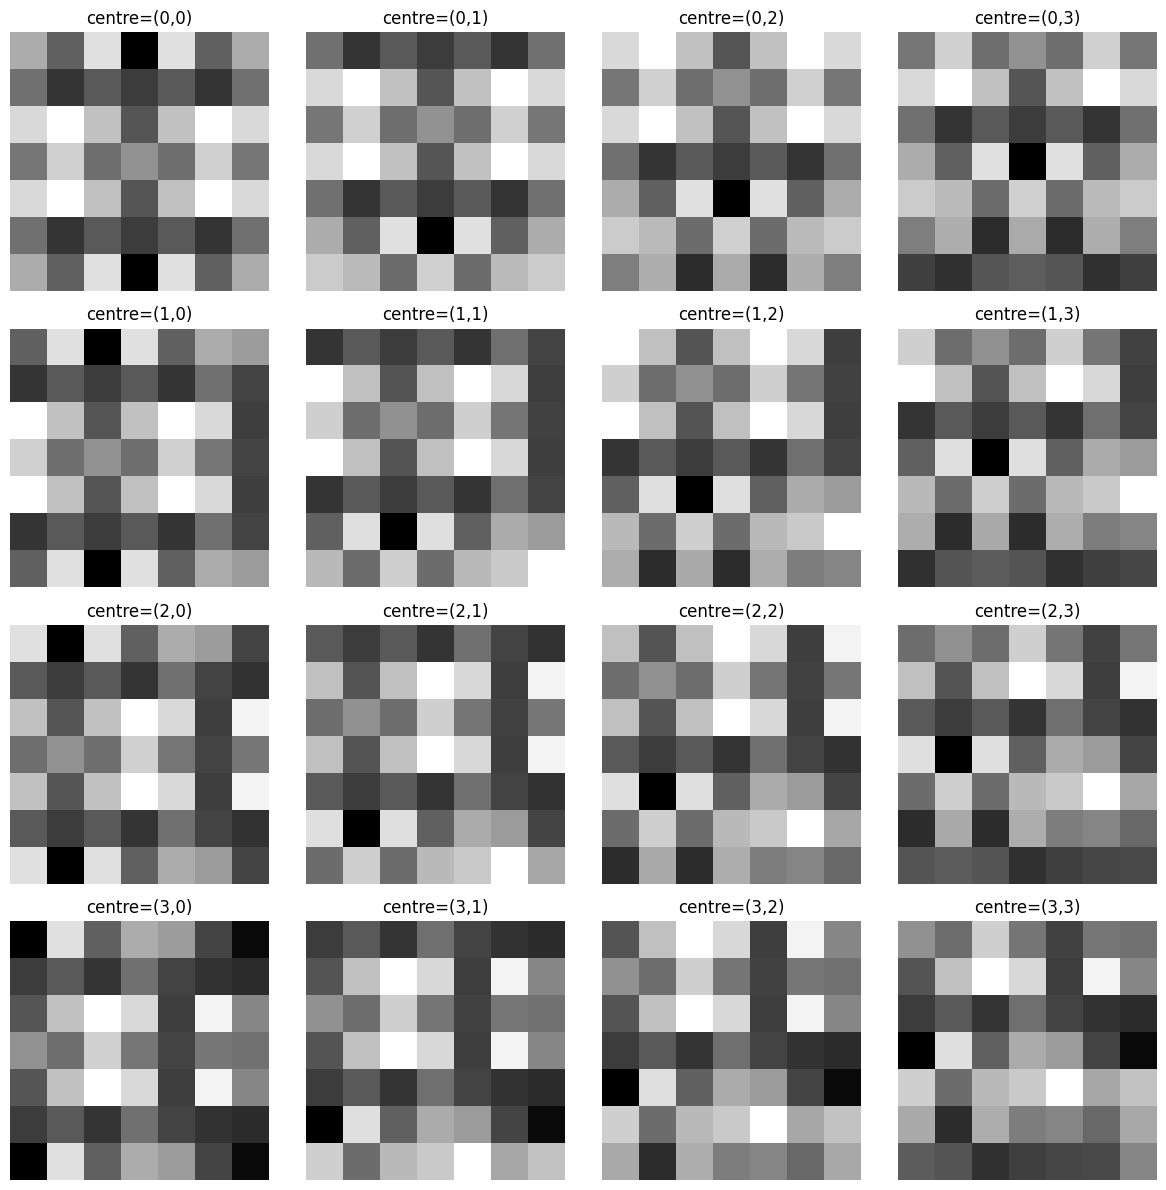

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# On affiche quelques patchs
fig, axes = plt.subplots(4, 4, figsize=(12,12))

coords = [
          (0, 0),(0, 1), (0, 2), (0, 3),
          (1, 0),(1, 1), (1, 2), (1, 3),
          (2, 0),(2, 1), (2, 2), (2, 3),
          (3, 0),(3, 1), (3, 2), (3, 3),
          ]  # centres (y, x)

# On calcule tous les patchs une fois pour toutes
matrxofpatch = patches(imgnoised_reshp)                  # P est un ndarray, shape (n, n, w1, w1)
print(f"La dimension de patch : {matrxofpatch.shape}\ndécrit un tenseur 4D qui code un patch 7×7\nautour de chaque pixel d’une image 128×128")

for i, (y, x) in enumerate(coords):
    ax = axes[i // 4, i % 4]
    one_patch = matrxofpatch[y, x]       # one_patch est 2D: shape (3,3)
    ax.imshow(one_patch, cmap='gray')
    ax.set_title(f"centre=({y},{x})")
    ax.axis('off')

plt.tight_layout()
plt.show()

### __`Réduction de dimension avec PCA`__
Comme les algorithmes de type Non Local-means nécessitent le calcul d’un grand nombre de distances entre les patchs, il est avantageux de réduire la dimension du patch tout en conservant le maximum d’informations possible.

In [14]:
# Dimension cible du patch
d = 25

`Une réduction de dimension est obtenue par l'Analyse des Composantes Principales (PCA)`:
- on projette les données sur un petit nombre de direction principales de la matrice de covariance des patchs. 
- on réorganise la matrice de patchs en un tableau de dimension $|(w1*w1,n*n)|$ 
- de sorte que `chaque colonne` $|P(:,i)|$ `soit un vecteur représentant un patch`. 

In [25]:
patch_matrix = lambda P:np.reshape(P,(w1*w1 ,n*n))

##### __`Un opérateur pour retirer la moyenne des patchs pour chaque patch`__ 
`L’idée est de centrer chaque patch, comme fait avec les données avant une ACP`
Si on précise en notation matricielle, avec $Q\in R^{d×N}$  : 
- $d=w_1^2$ le nombre de pixels par patch,
- $N = n * n$ le nombre de patchs,
- chaque colonne $Q(:,i)$ est un patch aplati.
Pour centrer chaque patch :
 - Pour chaque colonne i :
   - on calcule sa moyenne scalaire $m_i =mean(Q(:,i))$, 
   - on construit un nouveau vecteur  $Q_{centered} (:,i)=Q(:,i)−m_i1$, 
   - où 1 est un vecteur de 1 de taille d.

In [28]:
patch_centred = lambda patch_matrix:patch_matrix - np.mean(patch_matrix,axis=0, keepdims=True)

Calculer la moyenne et la covariance du nuage de point représentant les patchs.
 - $patch_{matrixReshp}(P)$ met tous les patchs dans une grande matrice 2D, puis 
 - $patch_{centrered}$ centrer chaque patchs comme fait sur les données avant une ACP et enfin 
 - construire la matrice de covariance CovMatrix = ptch_mtrx_rshp_cntrd @ ptch_mtrx_rshp_cntrd

$C$ calcule alors une matrice $(w1*w1 × w1*w1)$ proportionnelle à la matrice de covariance des patches
 -  on ne divise pas par $n*n$, mais pour l’ACP ça ne change pas les vecteurs propres.

In [90]:
# On calcule tous les patchs une fois pour toutes 
ptch_mtrx_rshp = patch_matrix(matrxofpatch)
ptch_mtrx_rshp_cntrd = patch_centred(ptch_mtrx_rshp)

# matrice de covariance (d, d)
# c’est la covariance d’échantillon “classique”, normalisée par N−1 (Bessel), 
# qui donne un estimateur non biaisé de la covariance.
cov_matrix = (ptch_mtrx_rshp_cntrd @ ptch_mtrx_rshp_cntrd.T) / (ptch_mtrx_rshp_cntrd.shape[1] - 1)

print(f"imgnoised.shape             : {imgnoised.shape}")
print(f"patch                       : {matrxofpatch.shape}")
print(f"ptch_mtrx_rshp (w1*w1, n*n) : {ptch_mtrx_rshp.shape}")
print(f"ptch_mtrx_rshp_cntrd        : {ptch_mtrx_rshp_cntrd.shape}")
print(f"Matrice de covariance       : {cov_matrix.shape}")

imgnoised.shape             : (128, 128)
patch                       : (128, 128, 7, 7)
ptch_mtrx_rshp (w1*w1, n*n) : (49, 16384)
ptch_mtrx_rshp_cntrd        : (49, 16384)
Matrice de covariance       : (49, 49)


Extraire les vecteurs propres triés par amplitude décroissante

V.shape : (49, 49)


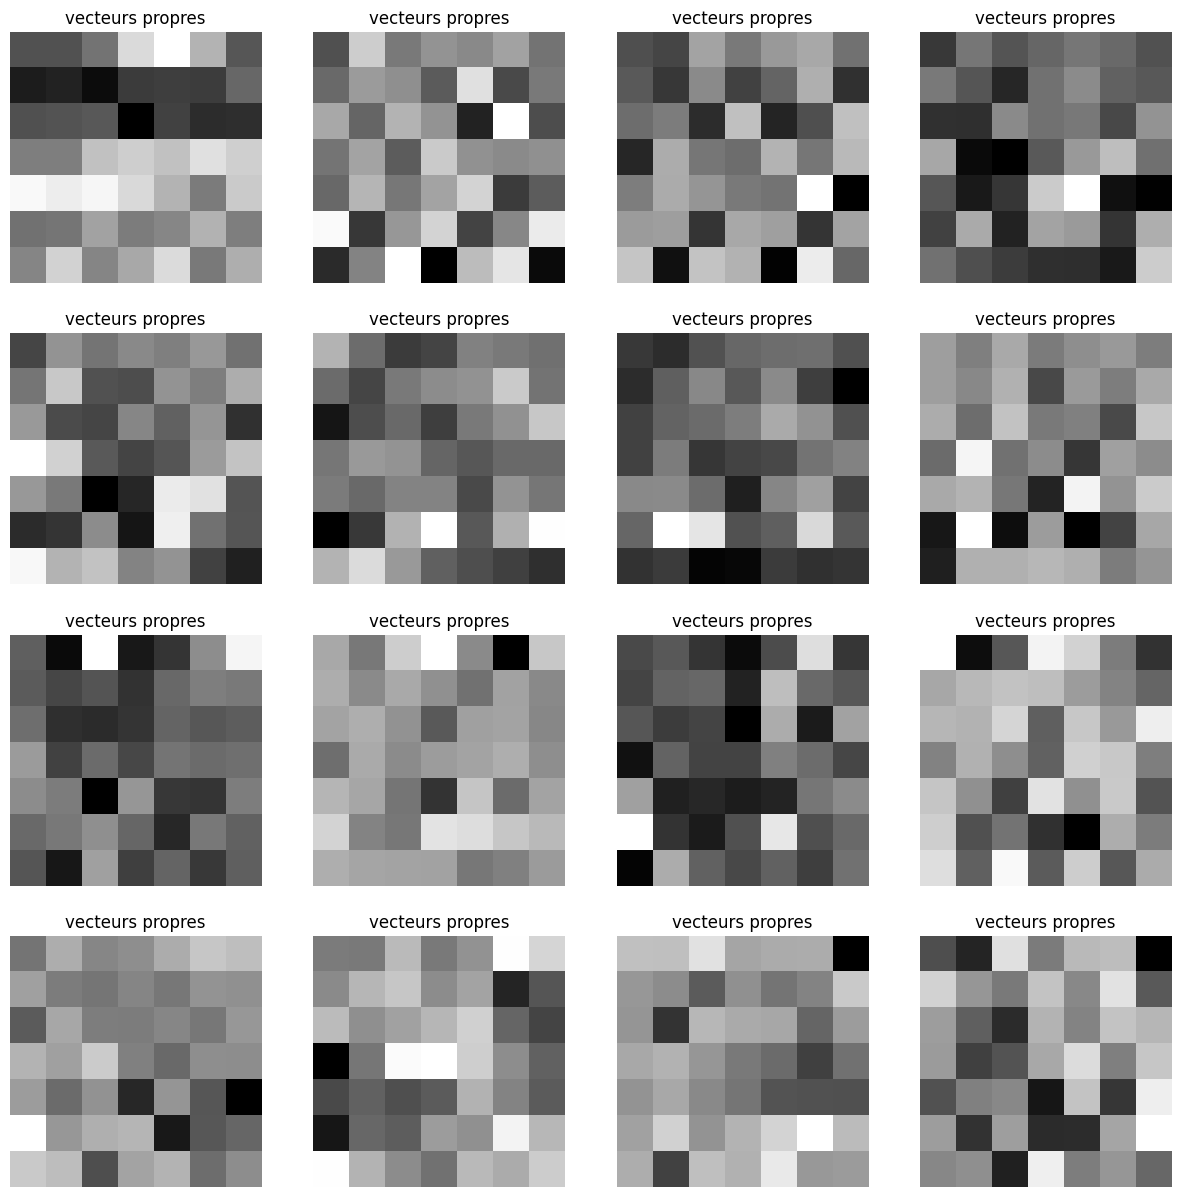

In [91]:
vals, vecs = np.linalg.eigh(cov_matrix)   # vecs.shape = (49, 49)
idx = np.argsort(vals)[::-1]
D = vals[idx]
V = vecs[:, idx]                          # (49, 49)
print(f"V.shape : {V.shape}")

plt.figure(figsize=(15,15))
for i in range(16):
    mode = V[:, i].reshape(w1, w1)        # 49 -> (7, 7), OK
    imageplot(mode, 'vecteurs propres', [4, 4, i+1])

Chaque représentation est un vecteur propre de la matrice de covariance des patchs, remis en forme 7×7.
- la cov_matrix capture comment les intensités des pixels d’un patch 7×7 varient ensemble.
- ses vecteurs propres V[:, i] sont les directions principales de variation → des “patterns typiques” de patchs.
- V.shape = (49, 49) → chaque vecteur propre est bien un patch 7×7 aplati.
- La visualisation des 16 premiers mode = V[:, i].reshape(7, 7) donne des “atomes” de patchs, 
- ils ressemblent à des motifs de texture locaux (un peu bruités, car l’image est bruitée).

Afficher la décroissance de l’amplitude des valeurs propres.

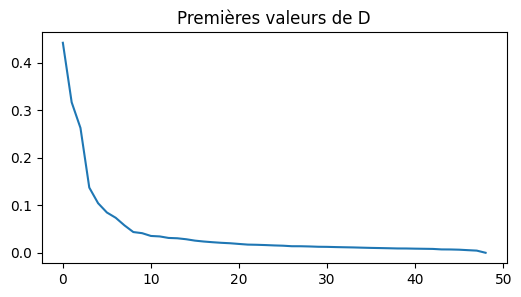

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(D)  # échelle log sur l'axe vertical
plt.title("Premières valeurs de D")
plt.show()

Le graphe montre les **valeurs propres** $D_i$ de ta matrice de covariance, triées décroissantes.
En PCA :
- Chaque valeur propre $D_i$ = **variance expliquée** par la composante principale $i$ (donc par le vecteur propre $V[:, i]$. 
- La courbe affiches est ce qu’on appelle souvent le **scree plot**.

`Que dit ce graphe :`
1. **Les premières valeurs sont grandes**, puis ça chute vite :
    -  → Quelques composantes (premiers vecteurs propres) capturent l’essentiel de la variance des patchs. 
2. __Vers le rang 10 à 15__, les valeurs propres deviennent petites et décroissent linéairement :  
    - → au delà ces composantes apportent peu d’information, elles modélisent surtout du bruit. 

`Conséquence pour la` __`réduction de dimension :`__

- On peut choisir un $d$ (nombre de composantes gardées) :
  - soit au “coude” de la courbe (là où elle se casse, typiquement ≈ 10),  
  - soit en imposant un pourcentage de variance cumulée (par ex. 95 %). 
- Ensuite, on projette chaque patch sur les $d$ premiers vecteurs propres :  
  - avant : patch ∈ $\mathbb{R}^{49}$,  
  - après : descripteur ∈ $\mathbb{R}^{d}$, tout en conservant la majeure partie de l’information.

Ce graphe **visualise le nombre de composantes utiles** pour compresser les patchs conservant leur contenu significatif.

#### __`Opérateur de réduction de dimensionnalité des patchs`__
Chaque $H(i,j,:)$ est un descripteur de patch de dimension d.

In [136]:
d = 15
V_d = V[:, :d]   # V est (w1*w1, w1*w1), V_d est (w1*w1, d)

resh   = lambda P: P.reshape(w1*w1, -1)                           # (d_full, N)
iresh  = lambda M: M.reshape(d, n, n).transpose(1, 2, 0)          # (n, n, d)
remove_mean = lambda M: (M - M.mean(axis=1, keepdims=True), M.mean(axis=1, keepdims=True))

def descriptor(P):
    M = resh(P)                  # (d_full, N)
    M_centered, mu = remove_mean(M)
    Z = V_d.T @ M_centered       # (d, N)   projection sur V_d
    return iresh(Z)              # (n, n, d) : descripteur k‑D par pixel

H = descriptor(ptch_mtrx_rshp)
print(f"{H.shape}")

(128, 128, 15)


Afficher les principaux vecteurs propres, ils ressemblent à des modes de Fourier

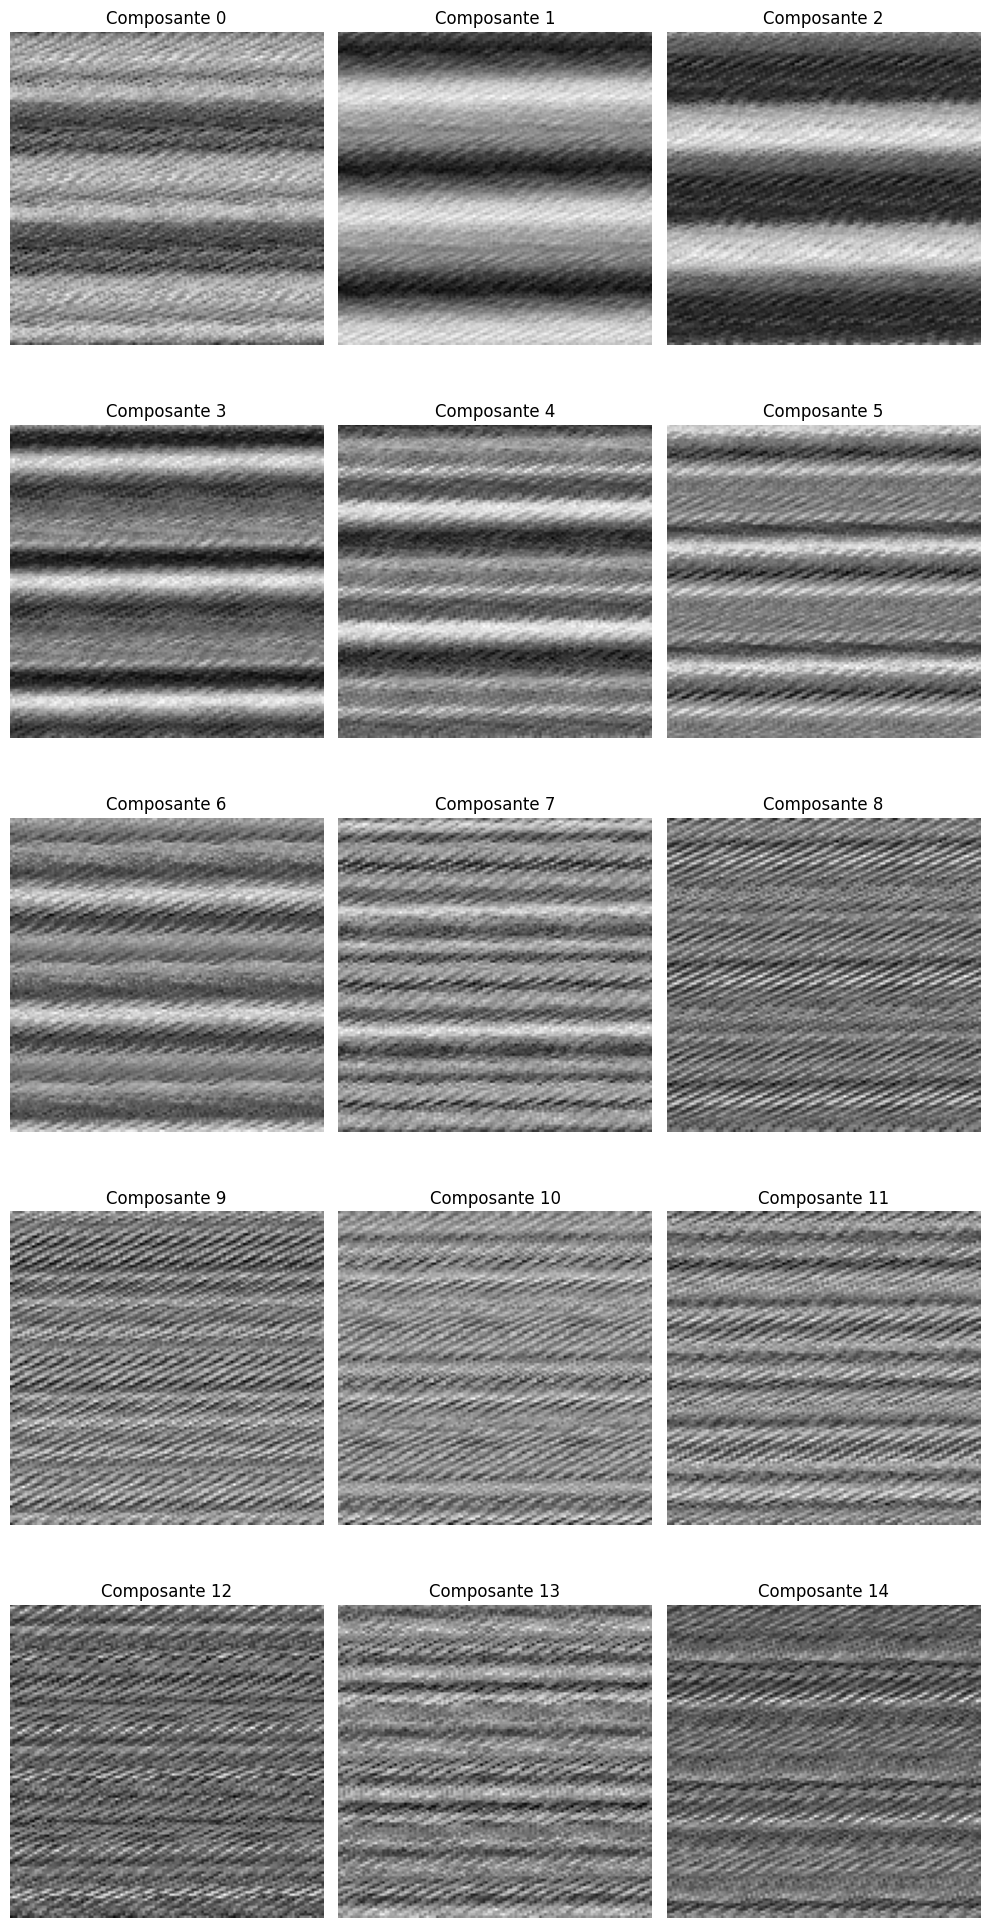

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# On affiche quelques patchs
fig, axes = plt.subplots(5, 3, figsize=(10,20))

for k in range(15):
    ax = axes[k // 3, k % 3]       
    ax.imshow(H[:,:,k] , cmap='gray')
    ax.set_title(f"Composante {k}")
    ax.axis('off')

plt.tight_layout()
plt.show()


En PCA, les vecteurs propres d’un champ stationnaire gaussien sont très proches des **fonctions propres de la covariance**, qui, pour des processus invariants par translation, sont justement des **harmoniques de Fourier** (ondes planes). 
- chaque carte $H[:,:,k]$ est la “réponse” de la composante principale $k$ au motif de base (l’image de franges).  
- les données (patchs) sont essentiellement des **ondes sinusoïdales quasi périodiques**; 
- leur base de variance maximale va ressembler à des **motifs sinusoïdaux** de différentes fréquences / orientations.  

Donc ce que l'on observe :  
- composantes basses (0–3) : structures plus lisses, “basses fréquences” (grandes franges),  
- composantes plus élevées : franges plus serrées → “hautes fréquences”.
- ce ne sont pas à base de Fourier, on fait une PCA sur patchs 7×7 réels, pas une TF complexe globale,
- **cela mime fortement des modes de Fourier locaux** adaptés à la texture de l'image.

### __`Filtre Non-local`__
Non-local-means applique à chaque pixel un noyau de moyenne adaptatif calculé sur la distance entre patchs
- On note $H_{i} \in \mathcal{R}^d$ le descripteur au pixel $i$.
- Nous définissons la distance entre matrix : $D_{i,j} = \frac{1}{w_1^2}||{H_i-H_j}||^2$
- Opérateur qui calcule les distances $(D_{i,j})_j$ entre le patch centré en $i=(i_1,i_2)$ et tous les autres.

In [ ]:
distance = lambda i: sum((H - repmat(H(i(1), i(2), : ), [n n 1])).^2, 3)/ (w1*w1)

The non-local mean filter compute a denoised image $\tilde f$ as
$$ \tilde f_i = \sum_j K_{i,j} f_j $$
where the weights $K$ are computed as
$$ K_{i,j} = \frac{ \tilde K_{i,j} }{ \sum_{j'} \tilde K_{i,j'} }
      \qandq
   \tilde K_{i,j} = e^{-\frac{D_{i,j}}{2\tau^2}} . $$



The width $\tau$ of the Gaussian is very important and should be adapted to match
the noise level.



Compute and normalize the weight.

In [ ]:
normalize = lambda K: K/ sum(K(: ))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
tau = .05
i = [83 72]
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

Localizing the Non-local Means
------------------------------
We set a "locality constant" $q$ that set the maximum distance between
patches to compare. This allows to speed up computation, and makes
NL-means type methods semi-global (to avoid searching in all the image).

In [ ]:
q = 14

Using this locality constant, we compute the distance between patches
only within a window.
Once again, one should be careful about boundary conditions.

In [ ]:
selection = lambda i: {clamp(i(1)-q: i(1) + q, 1, n), clamp(i(2)-q: i(2) + q, 1, n)}

Compute distance and kernel only within the window.

In [ ]:
distance = lambda i, sel: sum((H(sel{1}, sel{2}, : ) - repmat(H(i(1), i(2), : ), ...
        [length(sel{1}) length(sel{2}) 1])).^2, 3)/ (w1*w1)
distance = lambda i: distance(i, selection(i))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

The NL-filtered value at pixel $(x,y)$ is obtained by averaging the values
of $f$ with the weight $K$.

In [ ]:
NLval = lambda K, sel: sum(sum(K.*f(sel{1}, sel{2})))
NLval = lambda i, tau: NLval(kernel(i, tau), selection(i))

We apply the filter to each pixel location
to perform the NL-means algorithm.

In [ ]:
[Y, X] = meshgrid(1: n, 1: n)
NLmeans = lambda tau: arrayfun(lambda i1, i2: NLval([i1 i2], tau), X, Y)

Display the result for some value of $\tau$.

In [ ]:
tau = .03

imageplot(NLmeans(tau))

__Exercise 1__

Compute the denoising result for several values of $\tau$ in order to
determine the optimal denoising that minimizes $\norm{\tilde f - f_0}$.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Display the best result.

In [ ]:
imageplot(clamp(fNL))

__Exercise 2__

Explore the influence of the $q$ and $w$ parameters.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

Bibliography
------------
<html><a name="biblio"></a></html>


* [BuaCoMoA05] Buades, B. Coll, J.f Morel, [A review of image denoising algorithms, with a new one][1], SIAM Multiscale Modeling and Simulation, Vol 4 (2), pp: 490-530, 2005.

[1]:http://dx.doi.org/10.1137/040616024